<a href="https://colab.research.google.com/github/vituhaa/smile-detection/blob/main/smile_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings, zipfile, os, seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Activation, Dropout, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report

warnings.filterwarnings("ignore")

In [ ]:
# # выполняется один раз
# zip_path = '/content/drive/MyDrive/Smile-Classification.v1i.folder.zip'
# extract_path = '/content/drive/MyDrive/smile_ds'

# with zipfile.ZipFile(zip_path, 'r') as zip_ds:
#   zip_ds.extractall(extract_path)
#   print("датасет скачан")

датасет скачан


In [ ]:
TRAIN_PATH = os.path.join('/content/drive/MyDrive/smile_ds/train')
VAL_PATH = os.path.join('/content/drive/MyDrive/smile_ds/valid')
TEST_PATH = os.path.join('/content/drive/MyDrive/smile_ds/test')

In [ ]:
train_gen = ImageDataGenerator(rescale=1/255)
train_data = train_gen.flow_from_directory(
    TRAIN_PATH,
    target_size=(64, 64),
    class_mode='binary',
    color_mode='grayscale'
)

val_gen = ImageDataGenerator(rescale=1/255)
val_data = val_gen.flow_from_directory(
    VAL_PATH,
    target_size=(64, 64),
    class_mode='binary',
    color_mode='grayscale'
)

test_gen = ImageDataGenerator(rescale=1/255)
test_data = test_gen.flow_from_directory(
    TEST_PATH,
    target_size=(64, 64),
    class_mode='binary',
    color_mode='grayscale',
    shuffle=False
)

Found 9210 images belonging to 2 classes.
Found 2632 images belonging to 2 classes.
Found 1316 images belonging to 2 classes.


In [ ]:
model_baseline = Sequential([
    Conv2D(32, (3, 3), padding='same', input_shape=(64, 64, 1)),
    MaxPool2D(2, 2),
    Conv2D(64, (3, 3), padding='same'),
    MaxPool2D(2, 2),
    Flatten(),
    Dense(1, activation='sigmoid')
])

model_baseline.compile(loss='binary_crossentropy',
                       optimizer='adam',
                       metrics=['accuracy', 'precision', 'recall'])

model_baseline.summary()

In [ ]:
history_baseline = model_baseline.fit(train_data, epochs=10, validation_data=val_data, batch_size=40)

In [ ]:
loss, acc, precision, recall = model_baseline.evaluate(test_data)
print("Loss: ", loss, '\n',
      "Accuracy: ", acc, '\n',
      "Precision: ", precision, '\n',
      "Recall: ", recall)

42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - accuracy: 0.8936 - loss: 0.2672 - precision: 0.8949 - recall: 0.7078
Loss:  0.2672252357006073 
 Accuracy:  0.8936170339584351 
 Precision:  0.8949152827262878 
 Recall:  0.707774817943573


42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step
[[912  31]
 [109 264]]
              precision    recall  f1-score   support

    negative       0.89      0.97      0.93       943
    positive       0.89      0.71      0.79       373

    accuracy                           0.89      1316
   macro avg       0.89      0.84      0.86      1316
weighted avg       0.89      0.89      0.89      1316



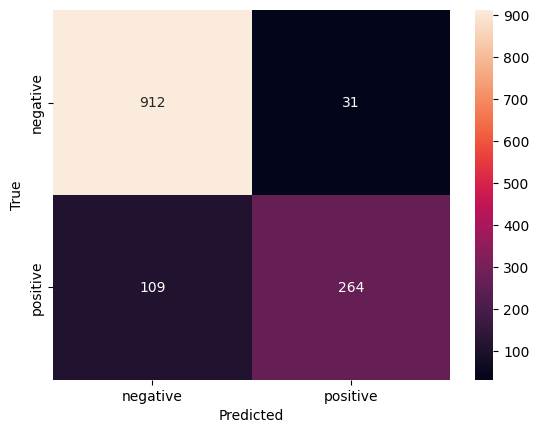

In [ ]:
probs = model_baseline.predict(test_data)
y_pred = (probs > 0.5).astype(int).ravel()
y_true = test_data.classes

matrix = confusion_matrix(y_true, y_pred)
print(matrix)
print(classification_report(y_true, y_pred, target_names=["negative", "positive"]))

sns.heatmap(matrix, annot=True, fmt='d',
            xticklabels=["negative", "positive"],
            yticklabels=["negative", "positive"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()